In [21]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import html
import emoji
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier

#only run once
nltk.download('punkt')
nltk.download('stop_words')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading stop_words: Package 'stop_words' not found
[nltk_data]     in index
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### **Business Understanding**

A real world problem for any business is finding out the general sentiment about one's product. The data can obviously be found in twitter but a challenge is gathering the data and finding the average sentiment about a product. If one was to perform this task manually they can spend a large amount of time to discover what the general public thinks about their product. For a business this can be fatal since if a product has bad general sentiments the business will lose money since customers will stop buying the product. It is important for businesses to quickly know what the public thinks of their product, so that any needed changes can be made to salvage both the reputation of a business and to maximize the profits.

One way to solve this issue is by using a prediction model that can tell one if the sentiments about a product are positive or negative.

The dataset we are using is a twitter dataset that was gathered by Crowdflower. 

The first column is the text of the tweet, the second column denotes whether they are talking about google or apple and the third column states whether the sentiment is positive or negative. 

The main goal of the project is to predict the sentiment of a tweet from raw text. 

The value of doing so is great to any business because one can pool information from social media and get an overview of the sentiments about a certain product. This can help a company know which of their products are the most popular. Which lets the company know which products they should invest more in. It can also tell a company which products are viewed unfavorably, so that the company can change the product. If a company is doing some A/B testing of a product through timed releases the sentiments online can be used to tell which version of a product is the best.

The business advantage of having reliable sentiment predictions is great. Shareholders as well as the workers in a company greatly benefit because of the reasons mentioned above. 

The requirements for creating a model that can predict sentiments from tweets are:
1. Raw Text from social media
2. Computational power to train the model
3. A team of data scientists to design the model
4. Labeled validation data to test the efficacy of a model


The challenges of this project are:
1. Gathering of textual data.
2. Cleaning the raw text so that it is readable by a model.


The solution to the problems above:
1. The CrowdFlower dataset gives one enough text scraped from twitter for one to perform the project.
2. The NLTK library and regex python libraries provide one with the tools to clean textual data.
3. The Sklearn python library will provide the models that will be trained on the cleaned textual data.



###  **Data Understanding**


Before building any models, we took time to understand the structure and contents of the dataset. This step was essential to identify what kind of information we were working with and how to prepare it effectively.

1. Dataset Overview
The dataset contains tweets that mention various brands or products. Along with each tweet, there's a label indicating the emotional response expressed toward the brand or product. These labels are useful for sentiment or emotion classification.

2. Main Columns
The most important columns in the dataset are:
tweet_text: The raw tweet content, which we use as the input feature.


is_there_an_emotion_directed_at_a_brand_or_product: The target label, which shows the type of emotional reaction (if any) present in the tweet.



3. Label Distribution
We examined the unique classes in the target column to understand the types and balance of emotional responses. The classes include:

Positive emotion


Negative emotion


No emotion toward brand or product


I can't tell


4. Missing Values
We found some tweets with missing content. These rows were dropped during data preparation to ensure clean input.

5. Text Characteristics
We observed the following traits in the tweet text:
Informal and noisy (containing emojis, hashtags, mentions, and URLs)


Varying lengths, from very short comments to longer sentences


Use of slang, repeated characters, and abbreviations


This confirmed that proper text preprocessing (like cleaning, tokenizing, and lemmatization) would be necessary to improve model accuracy.


### **Data Preparation**


To get our dataset ready for modeling, we followed a structured set of data cleaning and preprocessing steps. Below is a summary of everything we did:
1. Data Loading
We began by loading the dataset, which contains tweets about products and companies. This gave us access to the raw text data along with labels indicating whether there was an emotion directed at a brand or product.

2. Initial Inspection
We examined the dataset to understand its structure. This included checking the number of rows and columns, identifying any missing values, and getting a general sense of the data types. We also looked at the unique values in the target column to understand the kinds of emotional labels we would be working with.

3. Stopword Setup
Before processing the text, we prepared a list of English stopwords. These are common words like “the”, “and”, “is”, which usually don’t add much value to analysis and can be removed.

4. Text Cleaning
Since our dataset was based on tweets, the text was informal and often messy. To make it usable for modeling, we applied several cleaning steps:
Emoji Removal: Emojis were removed to reduce noise.


Hashtag and Mention Removal: We stripped out hashtags and user mentions (like @username) which were not relevant for our analysis.


Link Removal: Any links or URLs in the tweets were removed.


Special Character Filtering: We removed characters and symbols that were not letters, like punctuation or numbers.


Whitespace Handling: Extra spaces were cleaned up to make the text consistent.


Repeated Letters: Words with exaggerated letters (like “soooo” or “niiiice”) were cleaned by reducing excessive repetition.



5. Tokenization and Stopword Removal
We then broke each tweet into individual words — a process called tokenization — and removed the stopwords we had prepared earlier. This helped us focus only on the most meaningful words in each tweet.

6. Testing and Validation
To make sure our logic was working as expected, we tested some of the cleaning and filtering steps with simple examples. This helped us confirm that the functions we wrote were correctly removing or modifying the right parts of the text.

7. Pipeline Integration
We encapsulated many of these steps into a pipeline using Scikit-learn’s tools. This made the process repeatable and easier to manage. The pipeline also included vectorization (using TF-IDF) and later integrated with various machine learning models.


In [22]:
#reading the data into a dataframe
df = pd.read_csv('judge-1377884607_tweet_product_company.csv',encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


From the Non-Null Count we can see there is 1 tweet which is a null value. That probably means that the tweet is an empty string. 

I will drop this empty string before we do the training.

In [24]:
df.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect...,iPad,No emotion toward brand or product
freq,5,946,5389


In [25]:
#looking at the classes in the target column
df['is_there_an_emotion_directed_at_a_brand_or_product'].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

There are two columns that are useful in determining the sentiment of tweets.

These are:
1. tweet_text
2. is_there_an_emotion_directed_at_a_brand_or_product

The middle column which is called 'emotion_in_tweet_is_directed_at' is not useful for our aims. It will not be used in the training of the model.

In the cell below I will create a class named TweetPreprocessor.

This class will have functions for cleaning the text.

Transforming the dataframe.

And creating a fit for training.

I want to use this class within a pipeline. So I will have my class inherit from Sklearn's BaseEstimator and TransformerMixin libraries.

In [ ]:
# #I'm creating a class and inheriting from BaseEstimator and TransformerMixin
# #I'm doing this so that I can add this class into my pipeline
# class TweetPreprocessor(BaseEstimator, TransformerMixin):
#     def __init__(self, 
#                  remove_stopwords=True, 
#                  min_token_len=3, #i want to remove tokens that are less than length 2
#                  lemmatize_words=True,
#                  output_format='tokens'):  # 'tokens' or 'string' output. you can choose
#         self.lemmatizer = WordNetLemmatizer()
#         self.stop_words = set(stopwords.words('english')) #the set of english stopwords we are removing
#         self.remove_stopwords = remove_stopwords
#         self.min_token_len = min_token_len
#         self.lemmatize_words = lemmatize_words
#         self.output_format = output_format

#     def clean_text(self, text):
#         if not isinstance(text,str):
#             text = str(text) if text is not None else '' #ensuring that the data has a string format
#         # # 1. Unescape HTML
#         # text = html.unescape(text)

#         # 2. Remove emojis
#         text = emoji.replace_emoji(text, replace='') #using the emoji library that I imported above

#         # 3. Lowercase
#         text = text.lower()

#         # 4. Remove retweet tag
#         text = re.sub(r'^rt\s+', '', text)

#         # 5. Remove URLs
#         text = re.sub(r'https?://\S+', '', text)

#         # 6. Remove mentions, hashtags, and cashtags
#         text = re.sub(r'[@#\$]\w+', '', text)

#         # 7. Remove numbers
#         text = re.sub(r'\d+', '', text)

#         # 8. Reduce repeated characters (e.g. soooo → so)
#         text = re.sub(r'(.)\1{2,}', r'\1', text)

#         # 9. Remove non-alphabetic characters
#         text = re.sub(r'[^a-z\s]', '', text)

#         # 10. Normalize whitespace
#         text = re.sub(r'\s+', ' ', text).strip()

#         # 11. Tokenize
#         tokens = word_tokenize(text)

#         # 12. Filter stopwords and short tokens
#         if self.remove_stopwords:
#             tokens = [word for word in tokens if word not in self.stop_words]
#         if self.min_token_len > 0: #im removing tokens that are less than 3 words long.
#             tokens = [word for word in tokens if len(word) >= self.min_token_len] 

#         # 13. Lemmatize
#         if self.lemmatize_words:
#             tokens = [self.lemmatizer.lemmatize(word) for word in tokens]

#         if self.output_format == 'string':
#             return ' '.join(tokens)
#         return tokens

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         return X.apply(self.clean_text)


In [65]:

class TweetPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, 
                 remove_stopwords=True, 
                 min_token_len=3, 
                 lemmatize_words=True,
                 output_format='tokens'):  # 'tokens' or 'string'
        
        self.remove_stopwords = remove_stopwords
        self.min_token_len = min_token_len
        self.lemmatize_words = lemmatize_words
        self.output_format = output_format

        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def _is_english(self, text):
        try:
            return detect(text) == 'en'
        except:
            return False

    def clean_text(self, text):
        # --- Safety check ---
        if not isinstance(text, str):
            text = str(text) if text is not None else ''

        # --- Preprocessing Steps ---
        text = emoji.replace_emoji(text, replace='')                     # Remove emojis
        text = text.lower()                                              # Lowercase
        text = re.sub(r'^rt\s+', '', text)                               # Remove 'RT' tag
        text = re.sub(r'https?://\S+', '', text)                         # Remove URLs
        text = re.sub(r'[@#\$]\w+', '', text)                            # Remove mentions, hashtags, cashtags
        text = re.sub(r'\d+', '', text)                                  # Remove numbers
        text = re.sub(r'(.)\1{2,}', r'\1', text)                         # Reduce character repetition
        text = re.sub(r'[^a-z\s]', '', text)                             # Keep only letters and spaces
        text = re.sub(r'\s+', ' ', text).strip()                         # Normalize whitespace

        # --- Tokenization ---
        tokens = word_tokenize(text)

        # --- Filtering ---
        if self.remove_stopwords:
            tokens = [word for word in tokens if word not in self.stop_words]
        if self.min_token_len > 0:
            tokens = [word for word in tokens if len(word) >= self.min_token_len]
        if self.lemmatize_words:
            tokens = [self.lemmatizer.lemmatize(word) for word in tokens]

        # --- Return format ---
        return ' '.join(tokens) if self.output_format == 'string' else tokens

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Accept both list and Series (important for LIME compatibility)
        if isinstance(X, (list, pd.Series)):
            return [self.clean_text(text) for text in X]
        raise TypeError(f"Expected list or pd.Series, got {type(X)}")


## EDA Visualizations

In [27]:
#creating a copy of df to use for visualization
df_viz = df.copy()
df_viz.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In the cell below I will be transforming the dataframe using the class we created above.

I will also be creating a tokens column and a strings column

In [28]:
#transforming dataframe
# Initialize preprocessor
cleaner_tokens = TweetPreprocessor(output_format='tokens')
cleaner_string = TweetPreprocessor(output_format='string')

# Apply transformations
#creating column with tokens
df_viz['clean_tokens'] = cleaner_tokens.transform(df_viz['tweet_text'])
#creating column with strings
df_viz['clean_text'] = cleaner_string.transform(df_viz['tweet_text'])


In the cell below I am creating a visualization of the most frequent words

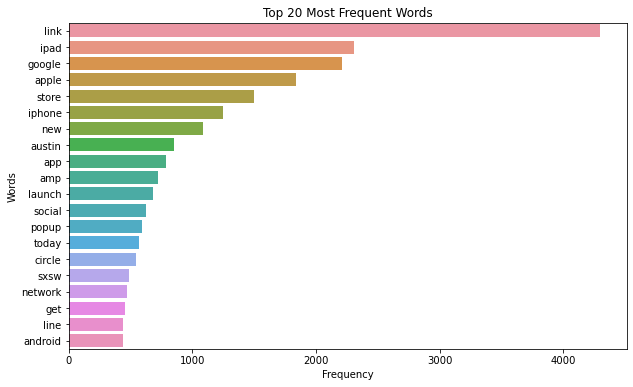

In [29]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten list of tokens
all_words = [word for tokens in df_viz['clean_tokens'] for word in tokens]
word_freq = Counter(all_words).most_common(20)

# Bar plot
words, freqs = zip(*word_freq)
plt.figure(figsize=(10,6))
sns.barplot(x=list(freqs), y=list(words))
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


I will then create a word cloud from the cleaned text column.

In the wordcloud the size of the word denotes its frequency.

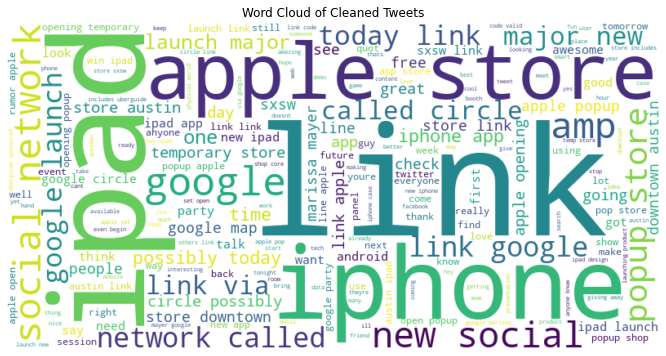

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = " ".join(df_viz['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Tweets")
plt.show()


In [31]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

I created a visualization to rank the most frequent words for the Positive emotion tweets

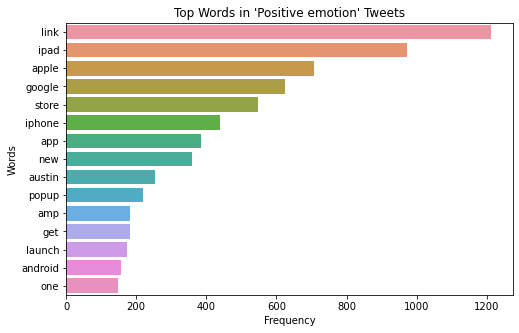

In [32]:
emotion_words = df_viz.groupby('is_there_an_emotion_directed_at_a_brand_or_product')['clean_tokens'].apply(lambda x: [word for tokens in x for word in tokens])

# Example: Top words for 'joy'
class_words = Counter(emotion_words['Positive emotion']).most_common(15)

# Plot
words, freqs = zip(*class_words)
plt.figure(figsize=(8,5))
sns.barplot(x=list(freqs), y=list(words))
plt.title("Top Words in 'Positive emotion' Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


I created a visualization to rank the most frequent words for the Negative emotion tweets

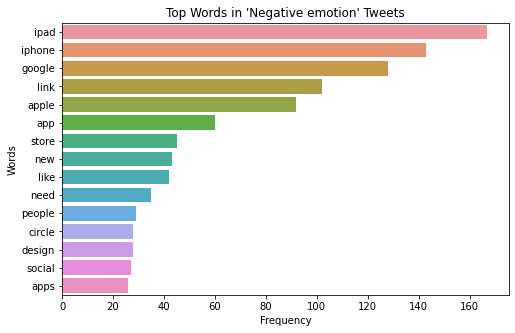

In [33]:
emotion_words = df_viz.groupby('is_there_an_emotion_directed_at_a_brand_or_product')['clean_tokens'].apply(lambda x: [word for tokens in x for word in tokens])

# Example: Top words for 'joy'
class_words = Counter(emotion_words['Negative emotion']).most_common(15)

# Plot
words, freqs = zip(*class_words)
plt.figure(figsize=(8,5))
sns.barplot(x=list(freqs), y=list(words))
plt.title("Top Words in 'Negative emotion' Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

I created a visualization to rank the most frequent words for the No emotion tweets

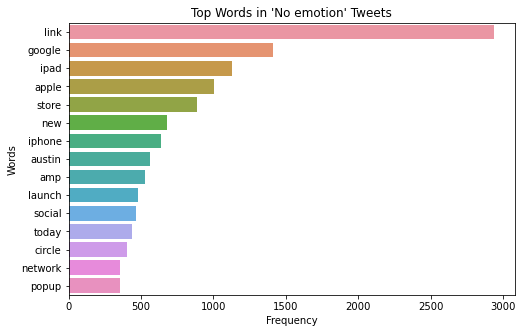

In [34]:
emotion_words = df_viz.groupby('is_there_an_emotion_directed_at_a_brand_or_product')['clean_tokens'].apply(lambda x: [word for tokens in x for word in tokens])

# Example: Top words for 'joy'
class_words = Counter(emotion_words['No emotion toward brand or product']).most_common(15)

# Plot
words, freqs = zip(*class_words)
plt.figure(figsize=(8,5))
sns.barplot(x=list(freqs), y=list(words))
plt.title("Top Words in 'No emotion' Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


In [35]:
#I am dropping all null rows from the raw text column
df = df.dropna(subset=['tweet_text'])

#I am splitting the data into the feature X and the target y
X = df['tweet_text']
y = df['is_there_an_emotion_directed_at_a_brand_or_product']


#I have a test size of 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [36]:
#I am creating the pipeline for the logistic regression model
pipeline_log = Pipeline([
    ('cleantweets',TweetPreprocessor(output_format='string')),
    ('vectorize',TfidfVectorizer()),
    ('model',LogisticRegression(max_iter=500,class_weight='balanced',random_state=42,n_jobs=-1))
])

In [37]:
#Here is the parameter grid for hyperparameter tuning of the logistic regression model
param_grid = {
    'vectorize__ngram_range': [(1, 1), (1, 2)],
    'vectorize__max_df': [0.8, 1.0],
    'vectorize__min_df': [1, 2],
    'model__C': [0.1,1, 10]  # Regularization strength
}

# Grid Search CV
grid = GridSearchCV(pipeline_log, param_grid, cv=3, scoring='f1_weighted', verbose=1)
grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'model__C': 10, 'vectorize__max_df': 0.8, 'vectorize__min_df': 1, 'vectorize__ngram_range': (1, 2)}


The logitic regression performance you see below is my baseline. 

In [38]:
# Predict on test set
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]  # Probability of class 1 (positive)

# Classification report for logistic_reg
print(classification_report(y_test, y_pred))

                                    precision    recall  f1-score   support

                      I can't tell       0.10      0.05      0.07        39
                  Negative emotion       0.43      0.34      0.38       151
No emotion toward brand or product       0.73      0.69      0.71      1320
                  Positive emotion       0.55      0.63      0.59       763

                          accuracy                           0.64      2273
                         macro avg       0.45      0.43      0.44      2273
                      weighted avg       0.64      0.64      0.64      2273



We will employ the use of stacked models in order to try improve on this perfomance.

The three models I will stack to create an ensemble model are LogisticRegression, SVC and XGBoost.

I am using these three models since they take a short time to run. And since I am stacking the three it won't take too long to train the ensemble model.

The final estimator I am using is the Logistic Regression Model.

In [66]:


# Preprocessing pipeline (you already have this)
text_pipeline = Pipeline([
    ('preprocess', TweetPreprocessor(output_format='string')),
    ('vectorizer', TfidfVectorizer())
])

# Base models
estimators = [
    ('lr', LogisticRegression(solver='liblinear')),
    ('svc', SVC(probability=True)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0))
]

# Stacking classifier
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Full pipeline: text preprocessing + stacking model
pipeline1 = Pipeline([
    ('text', text_pipeline),
    ('model', stack_model)
])


In [67]:
#training the ensemble model
pipeline1.fit(X_train, y_train)


c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('text',
                 Pipeline(steps=[('preprocess',
                                  TweetPreprocessor(output_format='string')),
                                 ('vectorizer', TfidfVectorizer())])),
                ('model',
                 StackingClassifier(cv=5,
                                    estimators=[('lr',
                                                 LogisticRegression(solver='liblinear')),
                                                ('svc', SVC(probability=True)),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               c...
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               n_estimators=100,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=None,
                                                               reg_alpha=None,
                                                               reg_lambda=None,
                                                               scale_pos_weight=None,
                                                               subsample=None,
                                                               tree_method=None,
                                                               use_label_encoder=False,
                                                               validate_parameters=None,
                                                               verbosity=0))],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

In [41]:
#classification report to see perfomance of model
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        39
                  Negative emotion       0.58      0.23      0.33       151
No emotion toward brand or product       0.70      0.84      0.76      1320
                  Positive emotion       0.63      0.51      0.57       763

                          accuracy                           0.68      2273
                         macro avg       0.48      0.40      0.42      2273
                      weighted avg       0.66      0.68      0.66      2273



c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


As we can see 68% accuracy is a big improvement in performance. 

The stacked models also improved the precision and recall of the Negative Emotion target class

In [42]:
# Meta model (final estimator)
final_estimator = LogisticRegression(solver='liblinear')
# Stacking model
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    passthrough=False,  # Optional: True if you want to include original features in meta-model
    n_jobs=-1,
    cv=3
)

# Full pipeline
pipeline = Pipeline([
    ('text', text_pipeline),
    ('model', stacking_model)
])

In [43]:
param_grid = {
    'model__lr__C': [0.1, 1],
    'model__svc__C': [0.1, 1],
    'model__svc__kernel': ['linear', 'rbf'],
    'model__xgb__n_estimators': [100, 200],
    'model__xgb__max_depth': [3, 5],
    'text__vectorizer__ngram_range': [(1, 1), (1, 2)]
    }

In [46]:
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV] END model__lr__C=0.1, model__svc__C=0.1, model__svc__kernel=linear, model__xgb__max_depth=3, model__xgb__n_estimators=100, text__vectorizer__ngram_range=(1, 1); total time=  26.8s
[CV] END model__lr__C=0.1, model__svc__C=0.1, model__svc__kernel=linear, model__xgb__max_depth=3, model__xgb__n_estimators=100, text__vectorizer__ngram_range=(1, 1); total time=  38.7s
[CV] END model__lr__C=0.1, model__svc__C=0.1, model__svc__kernel=linear, model__xgb__max_depth=3, model__xgb__n_estimators=100, text__vectorizer__ngram_range=(1, 1); total time=  44.9s
[CV] END model__lr__C=0.1, model__svc__C=0.1, model__svc__kernel=linear, model__xgb__max_depth=3, model__xgb__n_estimators=100, text__vectorizer__ngram_range=(1, 2); total time=  54.2s
[CV] END model__lr__C=0.1, model__svc__C=0.1, model__svc__kernel=linear, model__xgb__max_depth=3, model__xgb__n_estimators=100, text__vectorizer__ngram_range=(1, 2); total time=  53.8s
[CV] END mode

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('text',
                                        Pipeline(steps=[('preprocess',
                                                         TweetPreprocessor(output_format='string')),
                                                        ('vectorizer',
                                                         TfidfVectorizer())])),
                                       ('model',
                                        StackingClassifier(cv=3,
                                                           estimators=[('lr',
                                                                        LogisticRegression(solver='liblinear')),
                                                                       ('svc',
                                                                        SVC(probability=True)),
                                                                       ('xgb',
                                                                        XGBClassifier(base_score=None,
                                                                                      booster=None,
                                                                                      colsample_bylevel=...
                                                                                      validate_parameters=None,
                                                                                      verbosity=0))],
                                                           final_estimator=LogisticRegression(solver='liblinear'),
                                                           n_jobs=-1))]),
             n_jobs=1,
             param_grid={'model__lr__C': [0.1, 1], 'model__svc__C': [0.1, 1],
                         'model__svc__kernel': ['linear', 'rbf'],
                         'model__xgb__max_depth': [3, 5],
                         'model__xgb__n_estimators': [100, 200],
                         'text__vectorizer__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_weighted', verbose=2)

In [47]:
y_pred = grid.predict(X_test)
print("Best parameters:", grid.best_params_)
print("F1 score:", grid.best_score_)
print(classification_report(y_test, y_pred))

Best parameters: {'model__lr__C': 1, 'model__svc__C': 1, 'model__svc__kernel': 'rbf', 'model__xgb__max_depth': 3, 'model__xgb__n_estimators': 100, 'text__vectorizer__ngram_range': (1, 1)}
F1 score: 0.6601215377163117
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        39
                  Negative emotion       0.62      0.23      0.33       151
No emotion toward brand or product       0.70      0.84      0.76      1320
                  Positive emotion       0.63      0.51      0.56       763

                          accuracy                           0.68      2273
                         macro avg       0.49      0.40      0.41      2273
                      weighted avg       0.66      0.68      0.65      2273



c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\franc\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [86]:


def explain_prediction_with_lime(pipeline, X_test, class_names, idx, num_features=5, text_column='text'):
    """
    Explains prediction for a text sample using its actual index via LIME.

    Args:
        pipeline (Pipeline): Trained sklearn pipeline.
        X_test: Test set with text data.
        class_names (list): List of class names.
        idx (int/str): The actual index value of the row.
        num_features (int): Number of words to show in the explanation.
        text_column (str): Name of the column that contains the raw text.
        
    """
    # Get the actual text using .loc (based on index value)
    if isinstance(X_test, pd.Series):
        if idx not in X_test.index:
            raise ValueError(f"Index {idx} not found in X_test.")
        text_to_explain = X_test.loc[idx]
    elif isinstance(X_test, pd.DataFrame):
        if idx not in X_test.index:
            raise ValueError(f"Index {idx} not found in X_test.")
        if text_column not in X_test.columns:
            raise ValueError(f"Column '{text_column}' not found in X_test.")
        text_to_explain = X_test.loc[idx, text_column]
    else:
        raise TypeError("X_test must be a pandas Series or DataFrame.")

    # Create the explainer
    explainer = LimeTextExplainer(class_names=class_names)

    # Generate explanation
    explanation = explainer.explain_instance(
        text_instance=text_to_explain,
        classifier_fn=pipeline.predict_proba,
        num_features=num_features
    )

    # Display explanation
    explanation.show_in_notebook(text=True)

    # Print summary
    print(" Original Text:")
    print(text_to_explain)
    print(" Explanation (Top Features):")
    for word, weight in explanation.as_list():
        print(f"  {word}: {weight:.3f}")

class_names = [
    'No emotion toward brand or product',
    'Positive emotion',
    'Negative emotion',
    "I can't tell"
]

explain_prediction_with_lime(pipeline1, X_test, class_names, idx=697)


 Original Text:
shoot, my ipad will not display any search results :( will have to go through questions later #osmpw #sxsw
 Explanation (Top Features):
  questions: -0.015
  ipad: 0.005
  search: -0.003
  later: -0.002
  results: 0.001


We can see the function above is looking at row 711 in the X_test.

It shows that we have a 69% chance of the sentiment being negative. This is what caused the model to predict this as a negative sentiment

### **Recommendation**

The main issue with the dataset was:
1. High imbalance in target class
2. Some of the tweets weren't in english
3. The dataset was very messy and noisy
4. The dataset had outliers.

The main recommendations to improve upon the model would be:
1. Using SMOTE or undersampling to create a balanced target class, or we could collect more data.
2. When gathering the data, the non-english tweets should have been filtered out
3. In order to solve the noisy problem we can collect a much greater amount of data, so that our model can learn more general lessons.
4. More time can be placed into looking through the data to remove any outliers that aren't immediately recognizable.


